# 02 — Análisis de ejemplo: coyuntura, ARIMA y evaluación de pronósticos

Este notebook ilustra, con **una** serie, el tipo de análisis que el trabajo
exige para su variable objetivo:

1. Lectura desde la base de datos y visualización de coyuntura
2. Estimación de un modelo SARIMA
3. Evaluación de pronósticos **fuera de muestra** contra un benchmark ingenuo

> Este es un ejemplo mínimo con fines pedagógicos: su análisis debe ser más
> completo (dos modelos, análisis de relaciones con otras variables,
> discusión económica y de riesgos).

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

import carga_db

engine = carga_db.obtener_engine()

# Elegimos la primera serie mensual disponible como ejemplo
with engine.connect() as conn:
    serie_meta = pd.read_sql(
        text("SELECT id_serie, nombre FROM series WHERE frecuencia = 'M' LIMIT 1"), conn
    )
ID_SERIE = serie_meta.iloc[0]["id_serie"]
NOMBRE = serie_meta.iloc[0]["nombre"]
print(f"Serie de ejemplo: {NOMBRE} ({ID_SERIE})")

Serie de ejemplo: IPC, variación mensual (F074.IPC.VAR.Z.Z.C.M)


## 1. Lectura y visualización de coyuntura

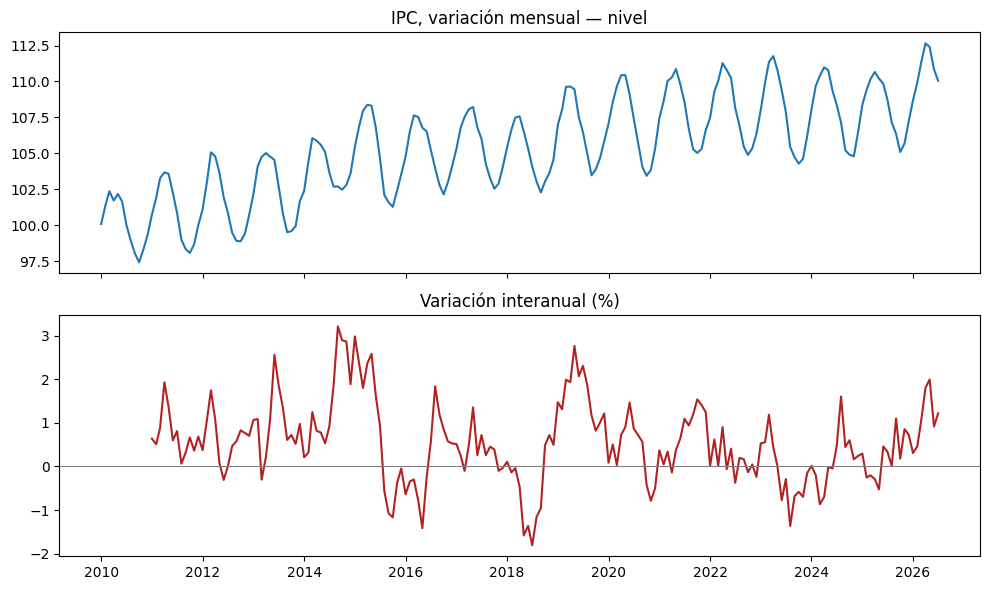

In [2]:
consulta = text("""
SELECT fecha, valor FROM observaciones
WHERE id_serie = :id ORDER BY fecha
""")
with engine.connect() as conn:
    df = pd.read_sql(consulta, conn, params={"id": ID_SERIE}, parse_dates=["fecha"])
df = df.set_index("fecha").asfreq("MS")

# Variación interanual (también puede venir calculada desde SQL)
df["var_ia"] = 100 * (df["valor"] / df["valor"].shift(12) - 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df.index, df["valor"])
axes[0].set_title(f"{NOMBRE} — nivel")
axes[1].plot(df.index, df["var_ia"], color="firebrick")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_title("Variación interanual (%)")
plt.tight_layout()
plt.show()

## 2. Modelo SARIMA

Estimamos un SARIMA(1,1,1)(1,0,1,12) como ejemplo. **Su trabajo debe
justificar la especificación** (tests de raíz unitaria, ACF/PACF, criterios
de información), no copiarla.

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

y = df["valor"].dropna()

modelo = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
resultado = modelo.fit(disp=False)
print(resultado.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                              valor   No. Observations:                  199
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -139.071
Date:                            Sun, 26 Jul 2026   AIC                            288.142
Time:                                    00:38:07   BIC                            304.583
Sample:                                01-01-2010   HQIC                           294.797
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 3. Evaluación de pronósticos fuera de muestra

La regla de oro: **en cada momento solo se puede usar información disponible
hasta esa fecha** (evitar *look-ahead bias*). Separamos los últimos 12 meses
como período de evaluación y comparamos contra un benchmark ingenuo
(el valor del mes anterior, equivalente a una caminata aleatoria).

In [4]:
H = 12  # meses de evaluación
entrenamiento, prueba = y.iloc[:-H], y.iloc[-H:]

# Pronóstico recursivo a 1 paso: re-estimamos con cada dato nuevo
pronosticos = []
historia = entrenamiento.copy()
for fecha in prueba.index:
    m = SARIMAX(historia, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
    r = m.fit(disp=False)
    pronosticos.append(r.forecast(1).iloc[0])
    historia = pd.concat([historia, prueba.loc[[fecha]]])  # agregamos el dato observado

pronosticos = pd.Series(pronosticos, index=prueba.index)
benchmark_ingenuo = y.shift(1).loc[prueba.index]  # valor del mes anterior

def rmse(obs, pred):
    return float(np.sqrt(np.mean((obs - pred) ** 2)))

print(f"RMSE SARIMA:            {rmse(prueba, pronosticos):.3f}")
print(f"RMSE benchmark ingenuo: {rmse(prueba, benchmark_ingenuo):.3f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RMSE SARIMA:            0.497
RMSE benchmark ingenuo: 1.223


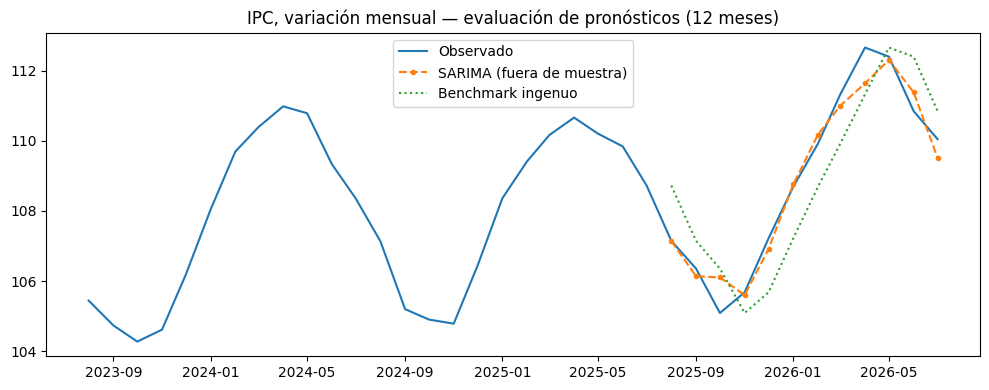

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y.iloc[-36:], label="Observado")
ax.plot(pronosticos, "--o", label="SARIMA (fuera de muestra)", ms=3)
ax.plot(benchmark_ingenuo, ":", label="Benchmark ingenuo")
ax.set_title(f"{NOMBRE} — evaluación de pronósticos ({H} meses)")
ax.legend()
plt.tight_layout()
plt.show()

### ¿Cómo leer este resultado?

- Si el RMSE del modelo **no supera** al benchmark ingenuo, el modelo no está
  agregando valor predictivo: eso también es un hallazgo y debe reportarse
  honestamente (en variables como el tipo de cambio será lo esperable).
- La comparación relevante para el informe incluye además un **segundo
  modelo** con variables explicativas (regresión con rezagos o ML del curso).

**Tareas del equipo:**
- Justificar la especificación del modelo con tests y criterios formales
- Agregar el segundo modelo y compararlo en la misma muestra de evaluación
- Interpretar económicamente los resultados y discutir riesgos del escenario